# Kernel Density Estimation
The key parameter is bandwidth (h), which controls the smoothing radius. Three bandwidths were selected based on nearest-neighbour distances in the dataset, and apply percentile-based thresholding to extract high-density zones.

In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity, BallTree
import warnings
warnings.filterwarnings('ignore')

print('imports done')

imports done


## 1. Load data

In [3]:
features = gpd.read_file("/Users/amber/Documents/M Thesis/Data/QGIS/isaura_features.gpkg")
parcel   = gpd.read_file("/Users/amber/Documents/M Thesis/Data/QGIS/08_isaura_extent_parcels.gpkg")
mounds   = features[features['type'] == 'mound'].copy()

print(f"Mound features: {len(mounds)}")
print(f"CRS: {mounds.crs}")

Mound features: 2671
CRS: EPSG:32644


## 2. Extract centroids

In [4]:
centroids = mounds.geometry.centroid
x = centroids.x.values
y = centroids.y.values
coords = np.column_stack([x, y])

print(f"n = {len(coords)}")
print(f"X range: {x.min():.0f} — {x.max():.0f} m")
print(f"Y range: {y.min():.0f} — {y.max():.0f} m")

n = 2671
X range: 364 — 21385 m
Y range: -5 — 15656 m


## 3. Build evaluation grid

The KDE surface is evaluated on a regular grid across the study area.

In [5]:
xmin, ymin, xmax, ymax = parcel.total_bounds
resolution = 200  # grid cells per axis

xgrid = np.linspace(xmin, xmax, resolution)
ygrid = np.linspace(ymin, ymax, resolution)
XX, YY = np.meshgrid(xgrid, ygrid)
grid_points = np.column_stack([XX.ravel(), YY.ravel()])

print(f"Grid: {resolution} x {resolution} = {resolution**2:,} cells")
print(f"Cell size: ~{((xmax-xmin)/resolution + (ymax-ymin)/resolution)/2:.0f} m")

Grid: 200 x 200 = 40,000 cells
Cell size: ~95 m


---
## 4. Scott's rule - automatic bandwidth

Scott's rule provides a statistically motivated starting point. It sets bandwidth as:

$$h = n^{-1/(d+4)} \cdot \sigma$$

where $n$ is the number of points, $d$ = 2 (dimensions), and $\sigma$ is the standard deviation per axis. This assumes a roughly Gaussian distribution, which may not hold for multimodal archaeological data, but it serves as a useful baseline.

In [7]:
kde_scott = gaussian_kde(coords.T, bw_method='scott')

factor   = kde_scott.factor
bw_x     = factor * x.std()
bw_y     = factor * y.std()
bw_scott = (bw_x + bw_y) / 2

print(f"Scott's factor: {factor:.4f}")
print(f"Bandwidth X: {bw_x:.1f} m")
print(f"Bandwidth Y: {bw_y:.1f} m")
print(f"Mean bandwidth: ~{bw_scott:.0f} m")

Scott's factor: 0.2685
Bandwidth X: 1127.4 m
Bandwidth Y: 786.6 m
Mean bandwidth: ~957 m


In [9]:
Z_scott = kde_scott(grid_points.T).reshape(resolution, resolution)

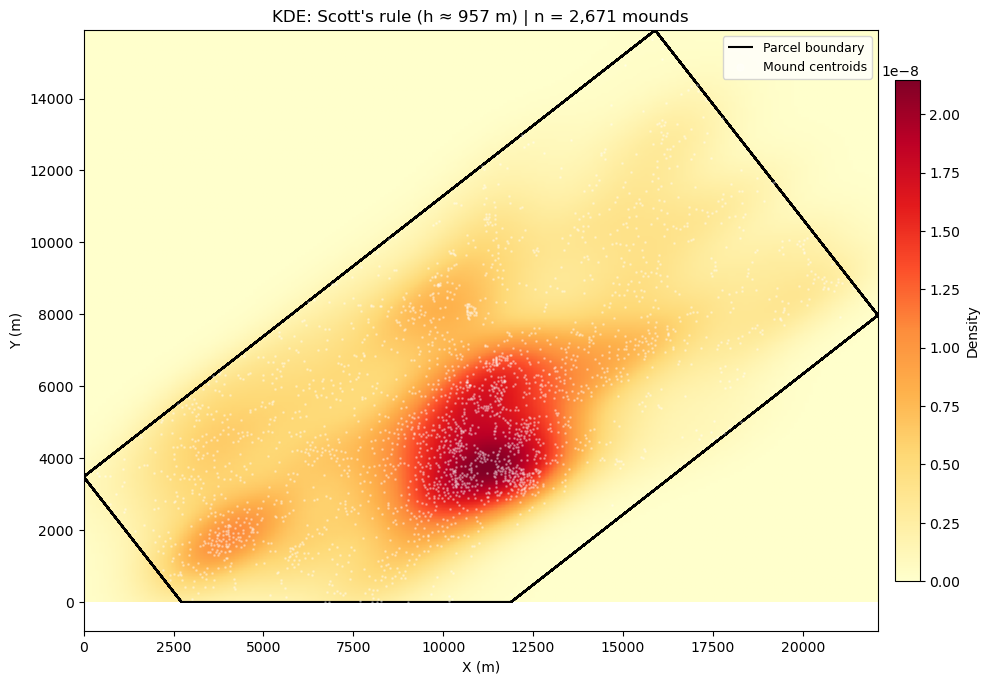

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(Z_scott, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='YlOrRd', aspect='equal')
parcel.boundary.plot(ax=ax, color='black', linewidth=1.5, label='Parcel boundary')
ax.scatter(x, y, s=1, color='white', alpha=0.3, label='Mound centroids', zorder=3)

fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Density')
ax.set_title(f"KDE: Scott's rule (h ≈ {bw_scott:.0f} m) | n = {len(coords):,} mounds", fontsize=12)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend(loc='upper right', fontsize=9, markerscale=5)

plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/kde_scotts_rule.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Bandwidth selection

### Nearest-neighbour distances

The nearest-neighbour distance (NND) is computed for each mound to ground the bandwidth choice in the structure of the data. Nakoinz & Knitter (2016) recommend using approximately three times the mean NND as the bandwidth for settlement-pattern KDE. I also look at distances to the 5th and 10th nearest neighbours to get a sense of local grouping scales.

In [11]:
# k=2 so that k=1 (self) is excluded
tree = BallTree(coords, metric='euclidean')

d2,  _ = tree.query(coords, k=2);  nnd1  = d2[:, 1]
d6,  _ = tree.query(coords, k=6);  nnd5  = d6[:, 5]
d11, _ = tree.query(coords, k=11); nnd10 = d11[:, 10]

mean_nnd = nnd1.mean()

print(f"Mean NND (k=1):  {mean_nnd:.1f} m")
print(f"Mean NND (k=5):  {nnd5.mean():.1f} m")
print(f"Mean NND (k=10): {nnd10.mean():.1f} m")
print(f"\n3 x mean NND: {3 * mean_nnd:.0f} m")

Mean NND (k=1):  120.1 m
Mean NND (k=5):  271.7 m
Mean NND (k=10): 395.4 m

3 x mean NND: 360 m


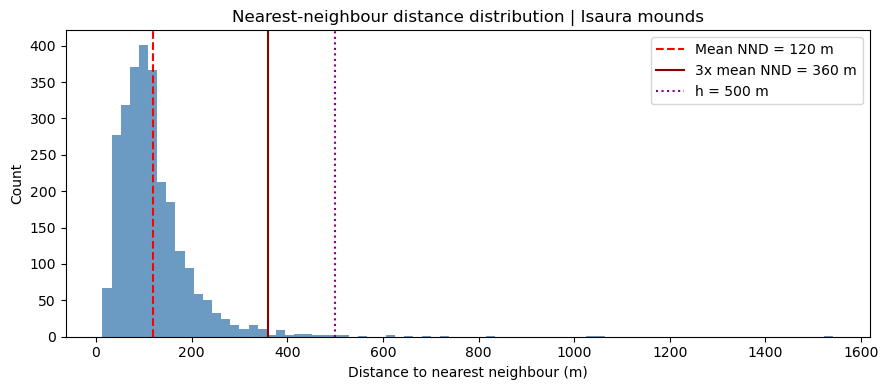

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(nnd1, bins=80, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(mean_nnd,       color='red',     linestyle='--', linewidth=1.5, label=f'Mean NND = {mean_nnd:.0f} m')
ax.axvline(3 * mean_nnd,   color='darkred', linestyle='-',  linewidth=1.5, label=f'3x mean NND = {3*mean_nnd:.0f} m')
ax.axvline(500, color='purple', linestyle=':', linewidth=1.5, label='h = 500 m')
ax.set_xlabel('Distance to nearest neighbour (m)')
ax.set_ylabel('Count')
ax.set_title('Nearest-neighbour distance distribution | Isaura mounds')
ax.legend()
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/kde_nnd_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Selected bandwidths

Three bandwidths are used:

- **120 m** - mean NND; captures fine-grained local mound clustering
- **360 m** - 3× mean NND, following Nakoinz & Knitter (2016); neighbourhood scale
- **500 m** - broader settlement scale

In [13]:
bandwidths = [120, 360, 500]

kde_surfaces = {}
for bw in bandwidths:
    kde = KernelDensity(bandwidth=bw, kernel='gaussian', algorithm='ball_tree')
    kde.fit(coords)
    Z = np.exp(kde.score_samples(grid_points)).reshape(resolution, resolution)
    kde_surfaces[bw] = Z
    print(f"h = {bw} m  done")

h = 120 m  done
h = 360 m  done
h = 500 m  done


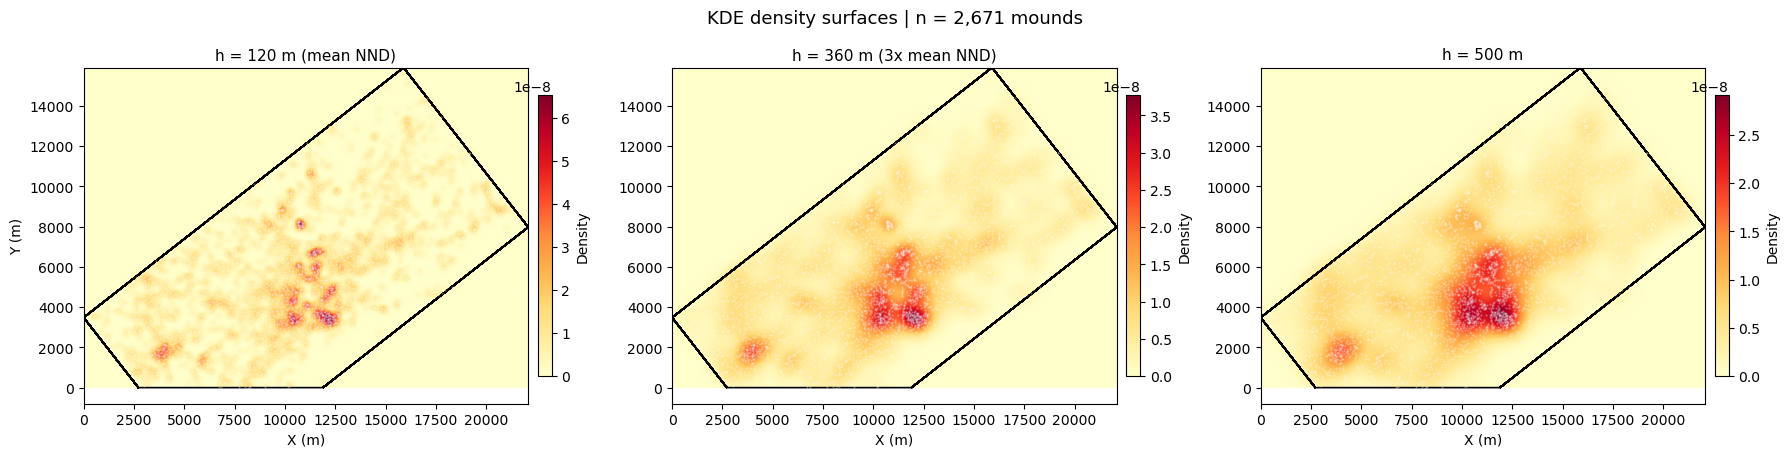

In [14]:
titles = {
    120: 'h = 120 m (mean NND)',
    360: 'h = 360 m (3x mean NND)',
    500: 'h = 500 m'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, bw in zip(axes, bandwidths):
    Z = kde_surfaces[bw]
    im = ax.imshow(Z, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='YlOrRd', aspect='equal')
    parcel.boundary.plot(ax=ax, color='black', linewidth=1.2)
    ax.scatter(x, y, s=0.5, color='white', alpha=0.25, zorder=3)
    ax.set_title(titles[bw], fontsize=11)
    ax.set_xlabel('X (m)')
    if ax == axes[0]:
        ax.set_ylabel('Y (m)')
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Density')

fig.suptitle(f'KDE density surfaces | n = {len(coords):,} mounds', fontsize=13, y=0.8)
plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/kde_bandwidth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Density thresholding

To extract discrete high-density zones from the KDE surface, a percentile-based threshold is applied: grid cells above the Nth percentile are classified as high-density. Three thresholds are tested (75th, 90th, 95th) for each bandwidth, producing one plot per bandwidth.

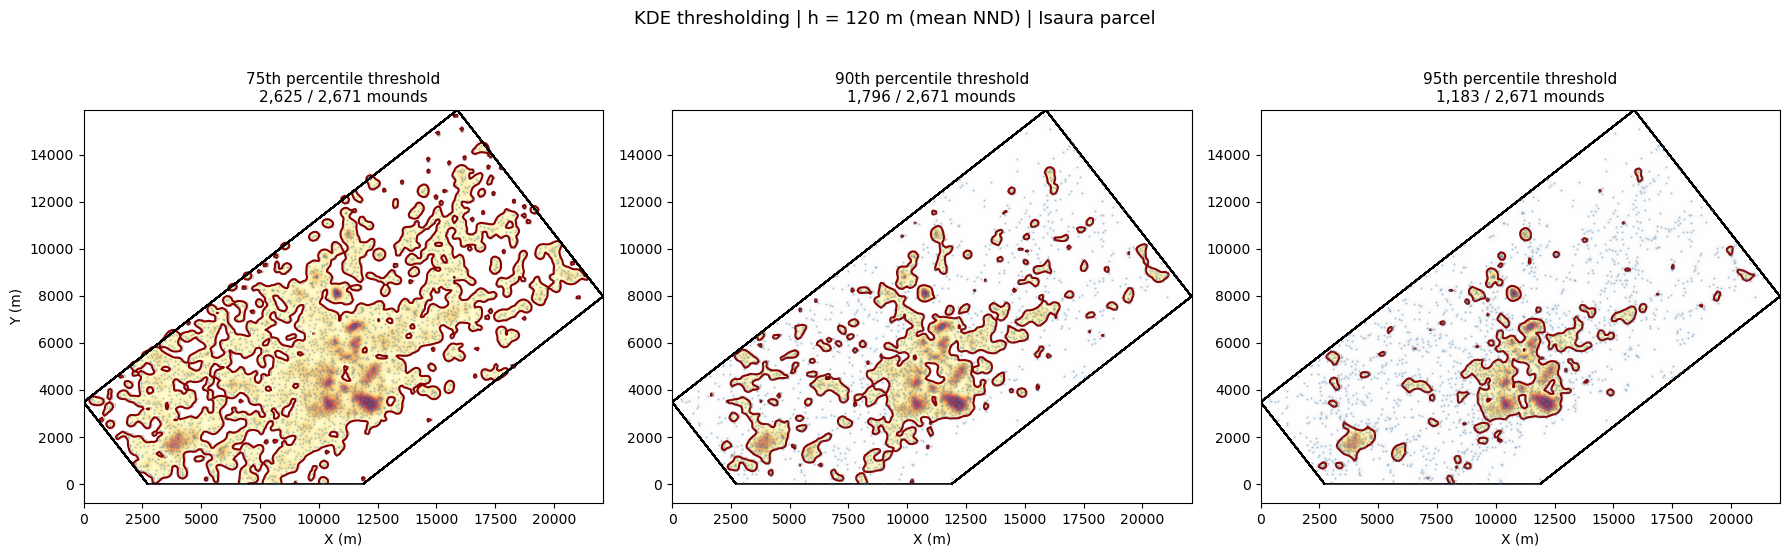

Saved: kde_thresholding_120m.png


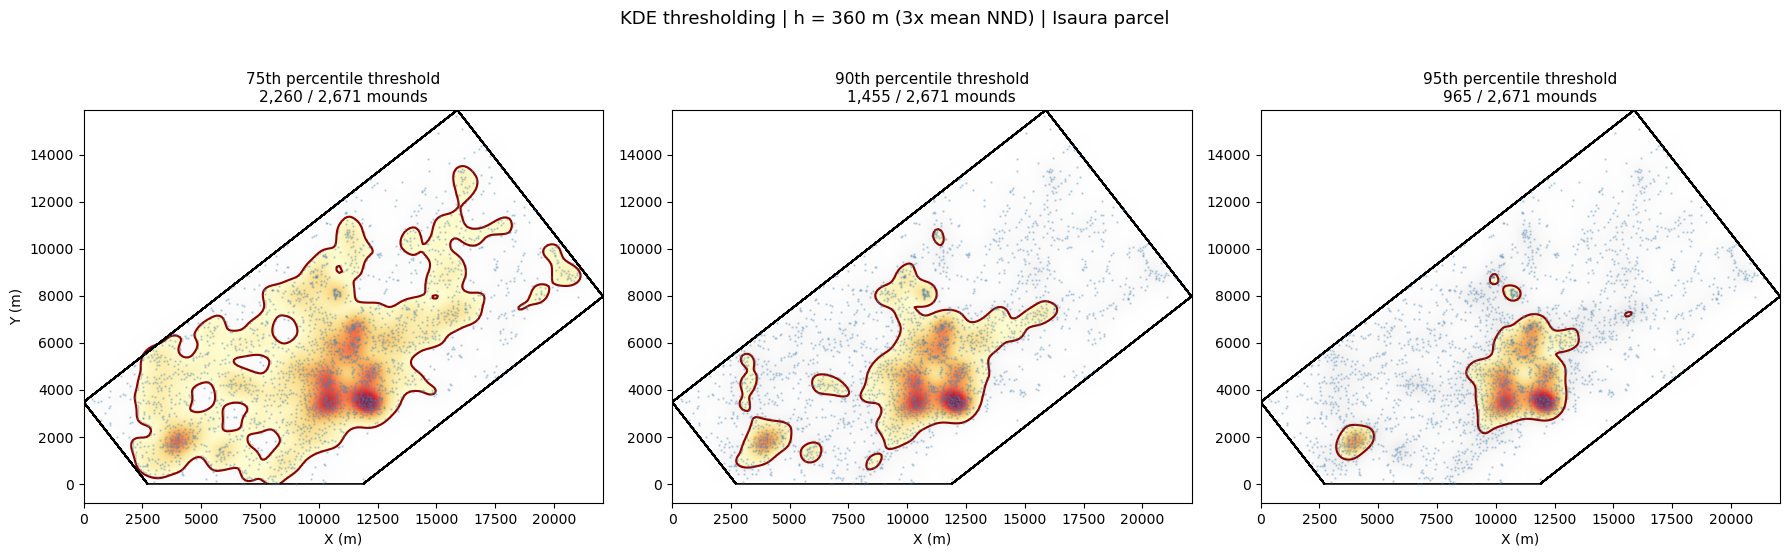

Saved: kde_thresholding_360m.png


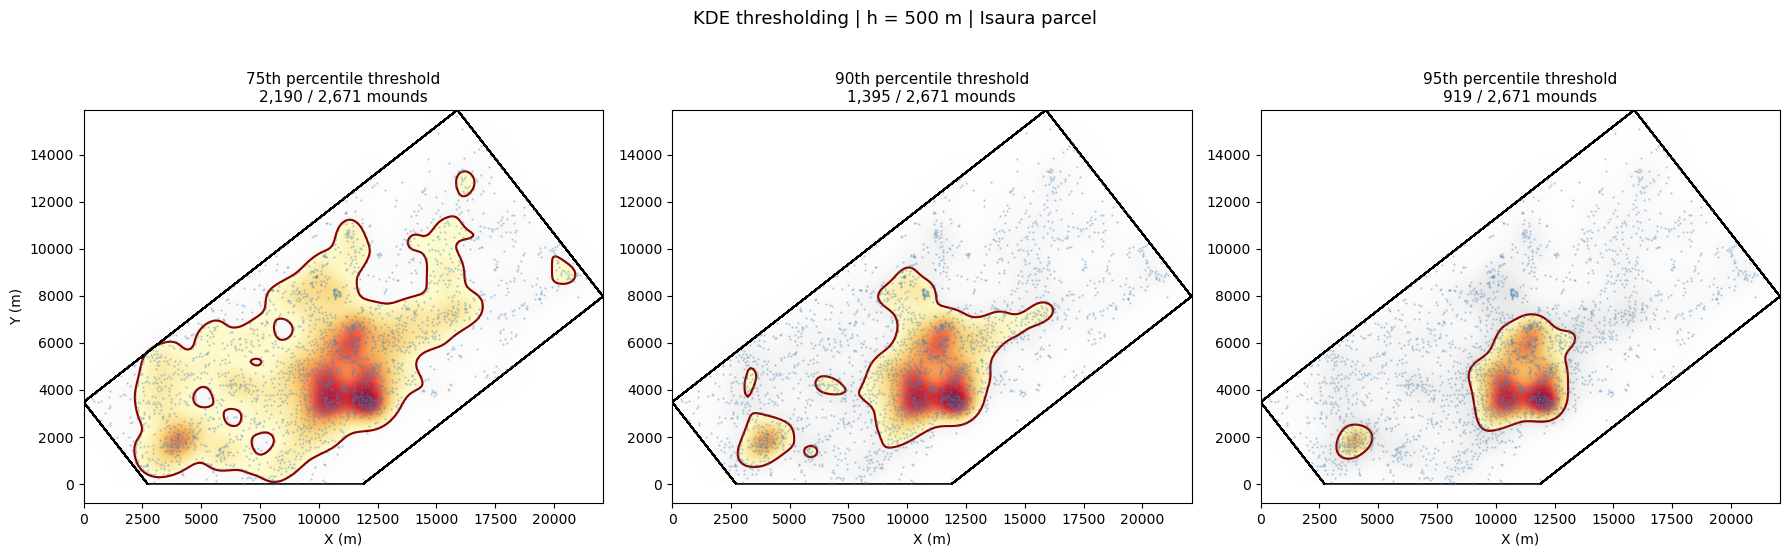

Saved: kde_thresholding_500m.png


In [15]:
percentiles = [75, 90, 95]

for bw in bandwidths:
    Z = kde_surfaces[bw]
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))

    for ax, pct in zip(axes, percentiles):
        threshold = np.percentile(Z, pct)
        mask = Z >= threshold

        # Faded full surface
        ax.imshow(Z, extent=[xmin, xmax, ymin, ymax], origin='lower',
                  cmap='Greys', alpha=0.4, aspect='equal')

        # High-density zones
        ax.imshow(np.where(mask, Z, np.nan), extent=[xmin, xmax, ymin, ymax],
                  origin='lower', cmap='YlOrRd', aspect='equal', alpha=0.85)

        # Threshold contour
        ax.contour(xgrid, ygrid, Z, levels=[threshold], colors='darkred', linewidths=1.5)

        parcel.boundary.plot(ax=ax, color='black', linewidth=1.2)
        ax.scatter(x, y, s=0.5, color='steelblue', alpha=0.3, zorder=3)

        # Count mounds inside high-density zones
        xi = np.searchsorted(xgrid, x).clip(0, resolution - 1)
        yi = np.searchsorted(ygrid, y).clip(0, resolution - 1)
        n_in = mask[yi, xi].sum()

        ax.set_title(f"{pct}th percentile threshold\n{n_in:,} / {len(coords):,} mounds", fontsize=11)
        ax.set_xlabel('X (m)')
        if ax == axes[0]:
            ax.set_ylabel('Y (m)')

    fig.suptitle(f'KDE thresholding | {titles[bw]} | Isaura parcel', fontsize=13, y=0.9)
    plt.tight_layout()
    plt.savefig(f'/Users/amber/Documents/M Thesis/Notebooks/kde_thresholding_{bw}m.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: kde_thresholding_{bw}m.png')

---
## 7. Summary table

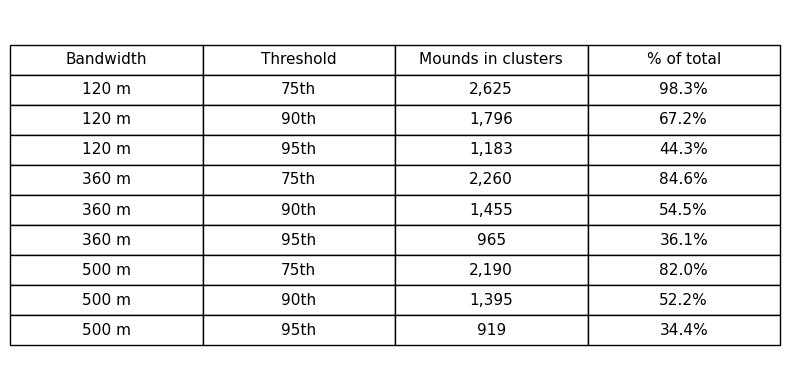

In [16]:
import matplotlib.pyplot as plt

# Build the table data
rows = []
for bw in bandwidths:
    Z = kde_surfaces[bw]
    for pct in percentiles:
        mask = Z >= np.percentile(Z, pct)
        xi   = np.searchsorted(xgrid, x).clip(0, resolution - 1)
        yi   = np.searchsorted(ygrid, y).clip(0, resolution - 1)
        n_in = mask[yi, xi].sum()
        rows.append([f'{bw} m', f'{pct}th', f'{n_in:,}', f'{100*n_in/len(coords):.1f}%'])

# Draw the table
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
table = ax.table(
    cellText=rows,
    colLabels=['Bandwidth', 'Threshold', 'Mounds in clusters', '% of total'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

plt.tight_layout()
plt.savefig('/Users/amber/Documents/M Thesis/Notebooks/kde_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()